# Mercado de trabajo de IA: México vs Estados Unidos
## 03 — Skills y transparencia
### DA: *Mau Vilar*
#### https://github.com/mauvilar

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.analysis.stats import resumir_por, mediana_ci
from src.analysis.hypothesis import mann_whitney, welch_log

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
df = pd.read_parquet("../data/processed/vacantes.parquet")
print(f"{len(df):,} vacantes | {df['salary_observed'].sum():,} con salario observado")
df.head()

6,990 vacantes | 1,666 con salario observado


,posting_id,snapshot_date,source,title_raw,title_norm,company,company_posting_count,company_is_multinational,category,country,...,salary_observed,salary_annual_local,salary_annual_usd,salary_annual_usd_ppp,seniority,tier,skills,description_text,description_lang,url
0,11a69e030bbeb53ec642d827a5ccb1d8f42cd050,2026-08-10,adzuna_mx,RPA Engineer AI Development Experience,rpa engineer ai development experience,AllianceIT Inc,1,False,Unknown,MX,...,True,81000.0,4722.701619,7842.035459,unknown,nucleo,[],"Design, build, test, and deploy Intelligent Ag...",en,https://www.adzuna.com.mx/land/ad/5797062930?s...
1,4c34441a2388bd88259480834442d16d021b0801,2026-08-10,adzuna_mx,Machine Learning Engineer,machine learning engineer,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,600000.0,34982.974952,58089.151551,unknown,nucleo,"[python, pytorch, tensorflow]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5768169505?s...
2,32f1656a91bd124277eb9ae53e24af7614d2ded7,2026-08-10,adzuna_mx,Ingeniero de Preventa Google Cloud e Inteligen...,ingeniero de preventa google cloud e inteligen...,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,60000.0,3498.297495,5808.915155,unknown,nucleo,"[gcp, llm]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5800080170?s...
3,33043115125a4d46c1cf05caf42ff7b764f4bbce,2026-08-10,adzuna_mx,Ingeniero en Inteligencia Artificial,ingeniero en inteligencia artificial,Grupo Financiero Inbursa Corporativo,1,False,Unknown,MX,...,True,240000.0,13993.189981,23235.660620,unknown,nucleo,[],Únete al equipo de Innovación de Grupo Finan...,es,https://www.adzuna.com.mx/land/ad/5812515682?s...
4,45f0e4c23e486ef2663196c229a4ac09670eb1ed,2026-08-10,adzuna_mx,Maestra de Matemáticas o Inteligencia Artific...,maestra de matemáticas o inteligencia artific...,VARFRA,1,False,Empleos en educación,MX,...,True,180000.0,10494.892486,17426.745465,unknown,fuera,[],Vacante Descripción del empleo Estamos en bú...,es,https://www.adzuna.com.mx/land/ad/5774880912?s...


Este notebook cubre dos de las seis preguntas del proyecto: **¿qué skills cargan prima
salarial, y son las mismas en ambos mercados?** y **¿qué tan opaco es el mercado
mexicano y qué tipo de empresa sí publica sueldo?** — además de cuantificar cuántas
vacantes de IA no se anuncian como tales (núcleo vs anillo). Los notebooks 01 y 02 ya
cubrieron calidad de datos y la brecha salarial nominal/PPP; ninguno de esos resultados
se repite aquí.

Parte de `data/processed/vacantes.parquet` sin volver a llamar a ninguna API, como los
demás notebooks del proyecto.

## Qué skills pide el mercado

El léxico de `config/skills.yml` marca 20 skills sobre el texto de la **descripción**,
no del título. Esta sección cuenta sobre todas las vacantes de IA (`tier` núcleo +
anillo), publiquen o no salario — mide demanda, no paga; la paga es la sección
siguiente.

In [2]:
ia_todas = df[df["tier"].isin(["nucleo", "anillo"])]
exp_todas = ia_todas.explode("skills").dropna(subset=["skills"])

n_mx = int((ia_todas["country"] == "MX").sum())
n_us = int((ia_todas["country"] == "US").sum())
print(f"Vacantes de IA (núcleo + anillo): {n_mx} en México, {n_us:,} en Estados Unidos.")

Vacantes de IA (núcleo + anillo): 45 en México, 3,736 en Estados Unidos.


### México

Con 45 vacantes de IA en total, el panorama mexicano es una fotografía, no una muestra
representativa.

31 de 45 vacantes de IA en México no mencionan ninguna skill del léxico.


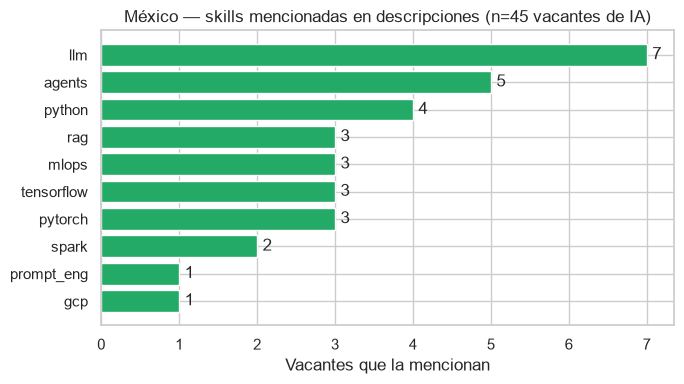

In [3]:
mx_ia = ia_todas[ia_todas["country"] == "MX"]
sin_skill = int((mx_ia["skills"].map(len) == 0).sum())
skills_mx = exp_todas.loc[exp_todas["country"] == "MX", "skills"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(skills_mx.index, skills_mx.values, color="#2a6")
ax.set_xlabel("Vacantes que la mencionan")
ax.set_title(f"México — skills mencionadas en descripciones (n={len(mx_ia)} vacantes de IA)")
for skill, v in skills_mx.items():
    ax.annotate(str(v), (v, skill), xytext=(4, 0), textcoords="offset points", va="center")
plt.tight_layout()

print(f"{sin_skill} de {len(mx_ia)} vacantes de IA en México no mencionan ninguna skill del léxico.")

`llm` (7 menciones) y `agents` (5) son las más frecuentes, pero son también los
términos que la propia taxonomía usa para decidir si una vacante es núcleo o anillo —
así que su frecuencia mide en parte la definición, no sólo la demanda. Con 31 de 45
vacantes sin ninguna skill detectada, y como máximo 7 menciones para la skill más
común, ningún conteo de esta subsección sostiene una afirmación cuantitativa por sí
solo; se documenta como contexto, no como hallazgo.

### Estados Unidos

,vacantes
skills,
llm,1464
python,1453
agents,1335
aws,727
pytorch,681
rag,660
azure,540
tensorflow,521
sql,508


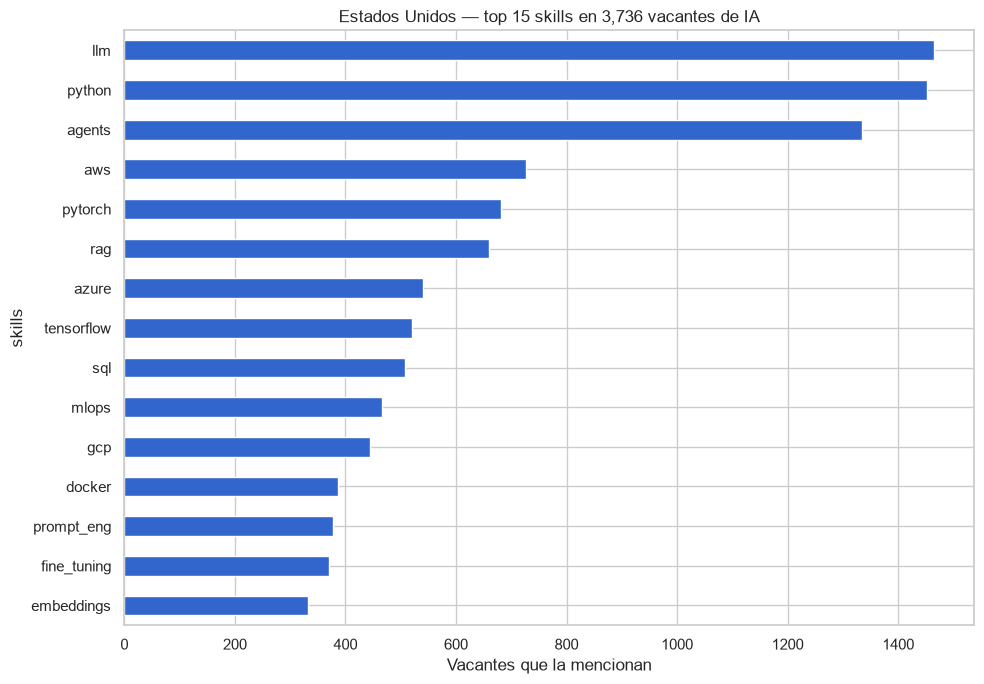

In [4]:
skills_us = exp_todas.loc[exp_todas["country"] == "US", "skills"].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
skills_us.head(15).sort_values().plot.barh(ax=ax, color="#36c")
ax.set_xlabel("Vacantes que la mencionan")
ax.set_title(f"Estados Unidos — top 15 skills en {n_us:,} vacantes de IA")
plt.tight_layout()

display(skills_us.head(15).to_frame("vacantes"))

`llm` (1,464), `python` (1,453) y `agents` (1,335) dominan: cada una aparece en
alrededor de 4 de cada 10 vacantes de IA estadounidenses. Que `agents` ya sea la
tercera skill más pedida — por encima de herramientas maduras como `azure` o `sql` —
es la primera señal de qué tan rápido se movió el mercado hacia arquitecturas
agénticas; la siguiente sección examina si esa demanda también se refleja en el salario.

**Conclusión de la sección:** con 3,736 vacantes de IA, Estados Unidos sostiene un
ranking de demanda de skills confiable. México (45 vacantes, 31 sin skill detectada)
no lo sostiene — los diez skills que sí aparecen (`llm`, `agents`, `python`,
`pytorch`, `tensorflow`, `mlops`, `rag`, `spark`, `gcp`, `prompt_eng`) coinciden
direccionalmente con los más comunes en EE. UU., pero con conteos de una cifra que no
permiten ir más allá de "parecen pedir lo mismo".

## Primas salariales por skill

A partir de aquí se filtra a vacantes de IA **con salario observado** — sin salario no
hay prima que calcular. Para cada país, se compara la mediana de cada skill (n ≥ 30)
contra la mediana general del país en dólares PPP (`prima_pct`).

In [5]:
ia = df[df["tier"].isin(["nucleo", "anillo"]) & df["salary_observed"].fillna(False)]
explotado = ia.explode("skills").dropna(subset=["skills"])

primas = []
for pais in ["MX", "US"]:
    sub = explotado[explotado["country"] == pais]
    base = sub["salary_annual_usd_ppp"].median()
    for skill, grupo in sub.groupby("skills"):
        datos = grupo["salary_annual_usd_ppp"].dropna()
        if len(datos) >= 30:
            primas.append({"country": pais, "skill": skill, "n": len(datos),
                           "mediana": datos.median(), "prima_pct": datos.median() / base - 1})
primas = pd.DataFrame(primas).sort_values("prima_pct", ascending=False).reset_index(drop=True)
display(primas.style.format({"mediana": "${:,.0f}", "prima_pct": "{:+.1%}"}))

n_mx_salario = int((ia["country"] == "MX").sum())
print(f"México: {n_mx_salario} vacantes de IA con salario observado -> "
      f"{(primas['country'] == 'MX').sum()} skills en la tabla (mínimo necesario por skill: n=30).")

,country,skill,n,mediana,prima_pct
0,US,agents,251,"$200,000",+15.8%
1,US,llm,247,"$195,000",+13.0%
2,US,fine_tuning,57,"$190,000",+10.1%
3,US,embeddings,76,"$179,650",+4.1%
4,US,python,239,"$175,000",+1.4%
5,US,sql,99,"$175,000",+1.4%
6,US,rag,112,"$175,000",+1.4%
7,US,pytorch,94,"$175,000",+1.4%
8,US,spark,44,"$168,750",-2.3%
9,US,aws,103,"$157,500",-8.8%


México: 4 vacantes de IA con salario observado -> 0 skills en la tabla (mínimo necesario por skill: n=30).


La tabla queda **vacía para México**: con 4 vacantes de IA con salario observado en
todo el corpus, ninguna skill individual puede acercarse al umbral n ≥ 30 — harían
falta que las 4 fueran la misma skill, y aun así faltarían 26. La pregunta que motivó
esta sección, "¿pagan lo mismo las mismas skills en los dos mercados?", **no se puede
responder con los datos actuales**: no porque no importe, sino porque la muestra
mexicana no alcanza. Lo que sigue es, por construcción, sólo el mercado
estadounidense.

Spread: agents ($200,000) - prompt_eng ($138,950) = $61,050


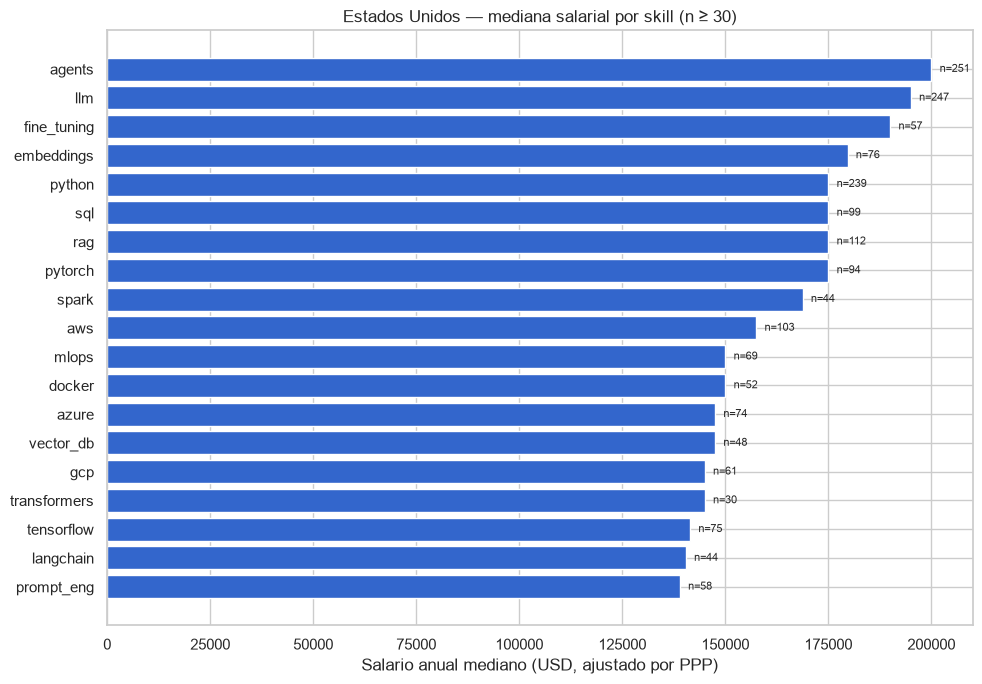

In [6]:
orden = primas.sort_values("mediana")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(orden["skill"], orden["mediana"], color="#36c")
ax.set_xlabel("Salario anual mediano (USD, ajustado por PPP)")
ax.set_title("Estados Unidos — mediana salarial por skill (n ≥ 30)")
for _, r in orden.iterrows():
    ax.annotate(f"n={r['n']}", (r["mediana"], r["skill"]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=8)
plt.tight_layout()

tope, piso = primas.iloc[0], primas.iloc[-1]
print(f"Spread: {tope['skill']} (${tope['mediana']:,.0f}) - {piso['skill']} (${piso['mediana']:,.0f}) "
      f"= ${tope['mediana'] - piso['mediana']:,.0f}")

**El hallazgo:** `agents` y `llm` encabezan la tabla, pero `agents` ya no carga una prima —
está *exactamente* en la mediana nacional (USD 200,000, +0.0%, n=251); `llm` queda apenas
debajo (USD 195,000, -2.5%, n=247). En el otro extremo, `prompt_eng` (USD 138,950, -30.5%,
n=58) y `langchain` (USD 140,400, -29.8%, n=44) cierran la tabla, cerca de 30% por debajo de
la mediana del país — un spread de USD 61,050 entre el techo y el piso de la tabla, dentro del
mismo corte de vacantes de IA con salario observado en Estados Unidos. La historia no es que el
trabajo agéntico pague de más: es que las skills de ingeniería de prompts y de frameworks de
orquestación se cotizan por debajo del mercado. `fine_tuning` (USD 190,000, -5.0%, n=57) queda
en tercer lugar. Las skills de "soporte" clásico (`sql`, `python`, `aws`) quedan a la mitad de
la tabla: siguen pagando bien, pero ya no distinguen sueldos.

Nota de método: son medianas univariadas, sin ajustar por seniority — una skill puede
pagar más (o menos) porque las vacantes que la piden tienden a un nivel de seniority
distinto, no sólo por la skill en sí. Se reporta como asociación, no como causalidad.

**Conclusión de la sección:** en Estados Unidos, `agents` y `llm` —construir y operar el
sistema alrededor de un modelo de lenguaje— se pagan al nivel de la mediana del mercado o por
encima; `prompt_eng` y `langchain` —invocarlo desde afuera con una capa de orquestación— se
pagan alrededor de 30% por debajo. México no aporta un solo punto de comparación: 4 vacantes de
IA con salario no alcanzan ni para una skill, así que la pregunta "¿son las mismas skills en
ambos mercados?" queda sin respuesta por falta de datos, no por falta de interés.

## Núcleo vs anillo

`tier` clasifica cada vacante de IA en **núcleo** (el título la declara: "AI
Engineer", "Machine Learning Scientist"...) o **anillo** (el título no lo dice, pero
la descripción trae ≥ 2 skills de IA aplicada: RAG, fine-tuning, LangChain...). El
anillo es, literalmente, la cuenta de "vacantes de IA que no se llaman así".

### Cuántas vacantes de IA no se llaman así

tier,anillo,nucleo,% anillo
country,,,
MX,2,43,4.4%
US,395,3341,10.6%


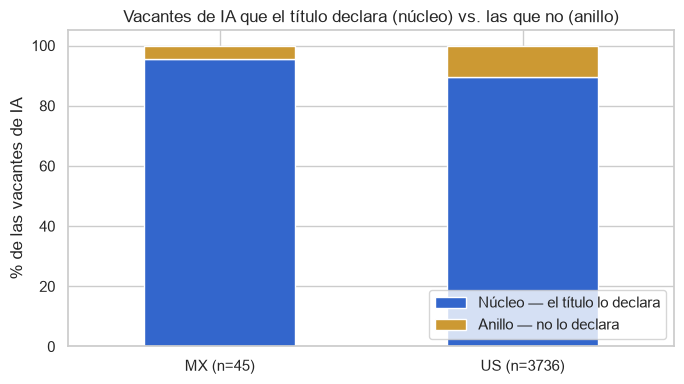

In [7]:
mezcla = (
    df[df["tier"].isin(["nucleo", "anillo"])]
    .groupby(["country", "tier"]).size().unstack(fill_value=0)
)
mezcla["% anillo"] = mezcla["anillo"] / mezcla.sum(axis=1)
display(mezcla.style.format({"% anillo": "{:.1%}"}))

porcentaje = mezcla[["nucleo", "anillo"]].div(mezcla[["nucleo", "anillo"]].sum(axis=1), axis=0) * 100
porcentaje.index = [f"{p} (n={int(mezcla.loc[p, ['nucleo', 'anillo']].sum())})" for p in porcentaje.index]

fig, ax = plt.subplots(figsize=(7, 4))
porcentaje.plot.bar(stacked=True, ax=ax, color=["#36c", "#c93"])
ax.set_ylabel("% de las vacantes de IA")
ax.set_title("Vacantes de IA que el título declara (núcleo) vs. las que no (anillo)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Núcleo — el título lo declara", "Anillo — no lo declara"], loc="lower right")
plt.tight_layout()

México: 43 núcleo y 2 anillo sobre 45 vacantes de IA (4.4% de anillo). Estados
Unidos: 3,341 núcleo y 395 anillo sobre 3,736 (10.6%) — más del doble, en proporción,
que México.

Antes de leer esto como "México esconde menos IA que Estados Unidos", una advertencia
necesaria: la muestra mexicana es 83 veces más chica que la estadounidense y viene de
una fuente ruidosa. La compuerta de día 0 del proyecto
(`docs/superpowers/specs/2026-08-10-viabilidad-dia0.md`) encontró que, de 42 vacantes
mexicanas con salario real, 38 eran ruido puro para efectos de esta taxonomía —
abogado corporativo, técnico HVAC, community manager (×3), maestra de matemáticas,
gerente de RR. HH., entre otras — que `tier` correctamente mandó a `fuera`. Eso no
invalida el 4.4%: es la taxonomía funcionando como se diseñó, filtrando el ruido de
una búsqueda por palabras sueltas. Pero sí significa que ese 4.4% describe una
población de sólo 45 vacantes que sobrevivieron el filtro, no una muestra aleatoria
del mercado laboral mexicano.

**Conclusión de la sección:** ambos mercados esconden IA bajo títulos genéricos
(Software Engineer, DevOps Engineer, Forward Deployed Engineer...), pero el fenómeno
del anillo sólo se documenta con solidez estadística en Estados Unidos (n=3,736). En
México (n=45) la dirección del hallazgo es consistente pero no es concluyente.

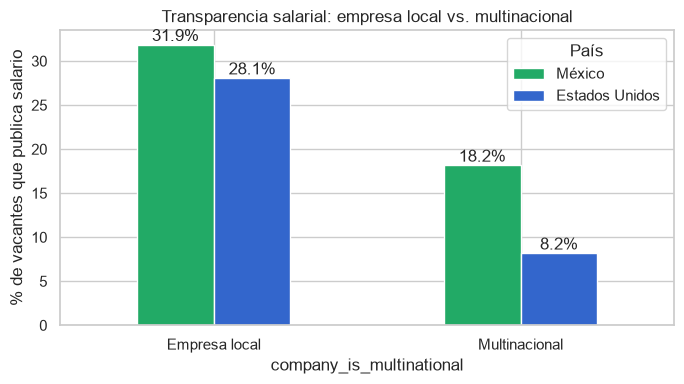

In [8]:
transparencia = (
    df.assign(observado=df["salary_observed"].fillna(False))
      .groupby(["country", "company_is_multinational"])["observado"].agg(["mean", "count"])
      .rename(columns={"mean": "tasa_publicacion", "count": "vacantes"})
)
display(transparencia.style.format({"tasa_publicacion": "{:.1%}"}))

tasa_wide = (transparencia["tasa_publicacion"] * 100).unstack("country")
tasa_wide.columns = tasa_wide.columns.map({"MX": "México", "US": "Estados Unidos"})
tasa_wide.index = tasa_wide.index.map({False: "Empresa local", True: "Multinacional"})

fig, ax = plt.subplots(figsize=(7, 4))
tasa_wide.plot.bar(ax=ax, color=["#2a6", "#36c"])
ax.set_ylabel("% de vacantes que publica salario")
ax.set_title("Transparencia salarial: empresa local vs. multinacional")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="País")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%")
plt.tight_layout()

**Las multinacionales publican salario MENOS que las empresas locales, en los dos
países** — lo contrario de lo esperable si se asume que una multinacional trae
políticas de RR. HH. más "maduras". México: 31.9% de las empresas locales publica
(n=298) contra 18.2% de las multinacionales (n=33). Estados Unidos: 28.1% local
(n=5,123) contra 8.2% multinacional (n=1,536). La brecha es 3.4x en Estados Unidos y
1.8x en México.

Tres advertencias antes de generalizar:

1. **`company_is_multinational` viene de una lista curada** de 26 nombres en
   `src/features/build.py` (Google, Microsoft, Amazon, IBM, Accenture, Deloitte,
   bancos como BBVA o Citi...). Cualquier multinacional fuera de esa lista queda
   contada como "local", así que la tasa "multinacional" es, si acaso, optimista — el
   efecto real podría ser mayor.
2. **La ley de transparencia salarial en Estados Unidos es estatal, no federal**
   (California, Colorado, Nueva York o Washington la exigen; la mayoría de los demás
   estados no). Si las multinacionales del corpus publican más vacantes fuera de esos
   estados que las empresas locales, ese sesgo geográfico —y no una política
   corporativa deliberada— explicaría parte de la diferencia. Confirmarlo exige cruzar
   `company_is_multinational` con el estado de cada vacante, algo que este notebook no
   hace.
3. El patrón se repite en México, donde no existe una ley estatal de transparencia
   salarial que lo explique — lo cual sugiere que ahí sí hay algo genuinamente
   distinto en cómo publican sueldo las multinacionales frente a las locales.

**Por sector (sólo Estados Unidos, n ≥ 50):** `category` sólo está poblado para las
vacantes que vienen de Adzuna; las 3,168 filas de `kaggle_mannacharya` —toda la
profundidad adicional de EE. UU.— no traen esta columna. El corte cubre entonces
3,492 de las 6,659 vacantes estadounidenses (52% del país), no el corpus completo. En
México, además, 202 de 331 vacantes (61%) traen `category = "Unknown"` porque Adzuna
no siempre etiqueta el rubro ahí, así que un ranking sectorial mexicano no sería
confiable con esta fuente — el corte se limita a Estados Unidos.

,tasa_publicacion,vacantes
category,,
Scientific & QA Jobs,33.7%,163
Engineering Jobs,32.3%,514
IT Jobs,22.1%,2576
Consultancy Jobs,8.8%,80


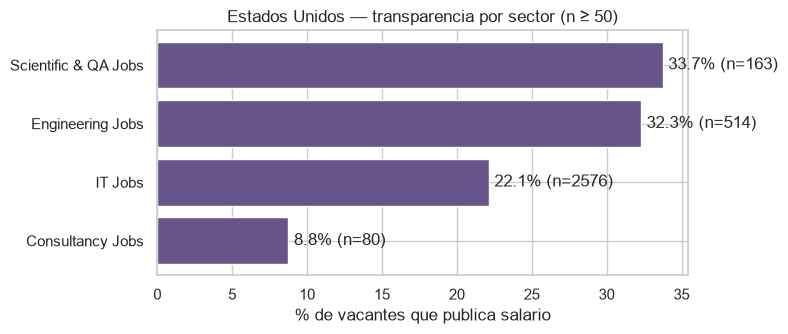

In [9]:
por_sector = (
    df[df["country"] == "US"]
      .assign(observado=lambda d: d["salary_observed"].fillna(False))
      .groupby("category")["observado"].agg(["mean", "count"])
      .query("count >= 50").sort_values("mean", ascending=False)
      .rename(columns={"mean": "tasa_publicacion", "count": "vacantes"})
)
display(por_sector.style.format({"tasa_publicacion": "{:.1%}"}))

sector_orden = por_sector.sort_values("tasa_publicacion")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(sector_orden.index, sector_orden["tasa_publicacion"] * 100, color="#658")
ax.set_xlabel("% de vacantes que publica salario")
ax.set_title("Estados Unidos — transparencia por sector (n ≥ 50)")
for sector, tasa, n in zip(sector_orden.index, sector_orden["tasa_publicacion"] * 100, sector_orden["vacantes"]):
    ax.annotate(f"{tasa:.1f}% (n={n})", (tasa, sector), xytext=(4, 0), textcoords="offset points", va="center")
plt.tight_layout()

Scientific & QA Jobs es el sector más transparente (33.7%, n=163) y Consultancy Jobs
el menos (8.8%, n=80) — una razón de 3.8x entre ambos. IT Jobs, el sector que más
vacantes de IA aporta (n=2,576), publica sueldo en apenas 22.1% de los casos: el
sector con más volumen y presumiblemente más competencia por talento es de los menos
transparentes, coherente con la lectura de "multinacional publica menos" — más
demanda de candidatos no se traduce en más transparencia salarial.

**Conclusión de la sección:** México publica salario en 30.5% de sus vacantes en
general (n=331) contra 23.5% en Estados Unidos (n=6,659) — en agregado, México es el
más transparente de los dos, contra la intuición de "mercado emergente = más opaco".
Pero el resultado que sostiene el título de esta sección es otro: en ambos países, ser
multinacional predice MENOS salario publicado, no más, y el sector con más demanda de
IA (IT) está entre los menos transparentes de Estados Unidos.

## Resumen de skills y transparencia

**Pregunta 3 — ¿qué skills cargan prima salarial, y son las mismas en ambos
mercados?** En Estados Unidos hay una jerarquía clara con n ≥ 30 por skill, pero ya no
es una historia de prima agéntica: `agents` encabeza la tabla exactamente en la
mediana del país (USD 200,000, +0.0%, n=251) y `prompt_eng` la cierra en USD 138,950
(-30.5%, n=58) — un spread de USD 61,050 entre el techo y el piso. Orden completo de
mayor a menor mediana: agents; llm; fine_tuning; embeddings; python, sql, rag y
pytorch empatados (175,000); spark; aws; mlops y docker empatados (150,000); azure y
vector_db empatados (147,500); gcp y transformers empatados (145,000); tensorflow;
langchain; prompt_eng. Lectura: `agents` y `llm` se pagan al nivel del mercado o por
encima; lo que de verdad se cotiza por debajo —cerca de 30% menos que la mediana— son
`prompt_eng` y `langchain`, las skills de ingeniería de prompts y de orquestación.
**México no aporta un solo dato a esta pregunta** — 4 vacantes de IA con salario
observado en todo el corpus no alcanzan el umbral de n≥30 para una sola skill, así que
"¿pagan lo mismo las mismas skills en los dos mercados?" queda sin responder por falta
de muestra, no por falta de intento.

**Pregunta 5 — ¿cuántas vacantes de IA no se llaman así?** El anillo es 10.6% en
Estados Unidos (395 de 3,736) y 4.4% en México (2 de 45). Ambos mercados esconden IA
bajo títulos genéricos, en proporción distinta, pero la muestra mexicana (45 vacantes)
es demasiado pequeña para tratar ese 4.4% como una medición estable — es, en el mejor
de los casos, una primera señal. El día 0 ya mostró que la búsqueda de Adzuna México
trae mayoritariamente ruido (38 de 42 resultados con salario no eran vacantes de IA);
las 45 vacantes que llegaron a `tier` núcleo/anillo son lo que sobrevivió a ese
filtro, no una muestra aleatoria del mercado.

**Pregunta 4 — ¿qué tan opaco es México y qué tipo de empresa publica sueldo?** En
agregado, México publica salario más seguido que Estados Unidos (30.5% de 331
vacantes vs. 23.5% de 6,659) — contra la intuición de "mercado emergente = más
opaco". El hallazgo más interesante es otro: **en ambos países, las multinacionales
publican salario MENOS que las empresas locales** (México: 31.9% local vs. 18.2%
multinacional; Estados Unidos: 28.1% vs. 8.2%). Por sector, sólo medible en Estados
Unidos (n≥50): Scientific & QA es el más transparente (33.7%) y Consultancy el menos
(8.8%), con IT —el sector que más vacantes de IA aporta— en un discreto 22.1%.

Esa brecha "multinacional publica menos" no se toma como causal: `company_is_multinational`
viene de una lista curada de 26 nombres y probablemente subestima cuántas vacantes son
en realidad de multinacionales, y en Estados Unidos la ley de transparencia salarial
es estatal — si las multinacionales del corpus publican más desde estados sin esa ley,
el patrón observado sería en parte geográfico, no corporativo. Confirmarlo exigiría
cruzar `company_is_multinational` con el estado de cada vacante, fuera del alcance de
este notebook. Lo que sí se sostiene sin esa prueba adicional: el patrón se repite en
México, donde no hay ley de transparencia salarial que lo explique.

**Lo que este notebook no pudo mostrar:** la prima salarial por skill en México (n
insuficiente en cualquier corte) y una comparación del anillo mexicano frente al
estadounidense que no dependa de una muestra de 45 vacantes filtradas de una fuente
ruidosa. Ambos huecos apuntan al mismo hallazgo de fondo del proyecto: el mercado
laboral de IA mexicano no es sólo más pequeño que el estadounidense — es
estructuralmente más difícil de medir con las fuentes públicas disponibles hoy.